In [1]:
# Import the necessary packages
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import product, chain
BASE_DIR = Path().resolve()

In [2]:
# Create a string and list to read in all files.
start_title = ["smithfield_sims_"]
election_title = ["Smithfield Council ", "Smithfield Mayor "]
demographics = ["Bachelor's Degree", "Black", "HS Degree", "Hispanic", "Some College Degree", "White"]
end_title = ["_BT.csv", "_PL.csv", "_Cam.csv"]

# Find every possible combination, then join into list of strings
csv_list = list(product(start_title, election_title, demographics, end_title))
csv_titles = [[''.join(elem)] for elem in csv_list] # Source: https://stackoverflow.com/questions/72186008/python-join-strings-in-list-of-lists; https://stackoverflow.com/questions/11264684/flatten-list-of-lists
csv_titles = list(chain.from_iterable(csv_titles)) # Flatten into one list 
# Now we have a list of all the csvs we need to read-in and analyze!

In [3]:
num_winners_boe = 3 # Manually set this by race
num_winners_council = 3 # Manually set this by race
num_simulations_per_race = len(demographics) * len(end_title) # Total number of combinations

In [4]:
# Read in all the csvs into a list of pandas dataframes
df_list = []

for i in csv_titles:
    df_list.append(pd.read_csv(BASE_DIR / "New_Simulation_Results" / "Elections" / "smithfield sims" / i))

smithfield_sims_Smithfield Council Bachelor's Degree_BT.csv
plurality winner:  ("['Doris Louise Wallace', 'John A. Dunn', 'Roger A. Wood']", 1885)
rcv winner:  ("['Doris Louise Wallace', 'John A. Dunn', 'Roger A. Wood']", 1908)
smithfield_sims_Smithfield Council Bachelor's Degree_PL.csv
plurality winner:  ("['Doris Louise Wallace', 'John A. Dunn', 'Roger A. Wood']", 1875)
rcv winner:  ("['Doris Louise Wallace', 'John A. Dunn', 'Roger A. Wood']", 1903)
smithfield_sims_Smithfield Council Bachelor's Degree_Cam.csv
plurality winner:  ("['Doris Louise Wallace', 'Roger A. Wood', 'Stuart Ashby Lee']", 1905)
rcv winner:  ("['Doris Louise Wallace', 'Roger A. Wood', 'Stuart Ashby Lee']", 1106)
smithfield_sims_Smithfield Council Black_BT.csv
plurality winner:  ("['John A. Dunn', 'Roger A. Wood', 'Stephen Rabil']", 9996)
rcv winner:  ("['John A. Dunn', 'Roger A. Wood', 'Stephen Rabil']", 7351)
smithfield_sims_Smithfield Council Black_PL.csv
plurality winner:  ("['John A. Dunn', 'Roger A. Wood', 'S

/var/folders/tx/qckl6gp57yq_ckc0ywsl5vlh0000gn/T/ipykernel_46626/4239630233.py:65: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


smithfield_sims_Smithfield Mayor Black_BT.csv
plurality winner:  ("['Andy Moore']", 10000)
rcv winner:  ("['Andy Moore']", 10000)
smithfield_sims_Smithfield Mayor Black_PL.csv
plurality winner:  ("['Andy Moore']", 10000)
rcv winner:  ("['Andy Moore']", 10000)
smithfield_sims_Smithfield Mayor Black_Cam.csv
plurality winner:  ("['Andy Moore']", 10000)
rcv winner:  ("['Andy Moore']", 10000)
smithfield_sims_Smithfield Mayor HS Degree_BT.csv
plurality winner:  ("['Andy Moore']", 9999)
rcv winner:  ("['Andy Moore']", 9998)
smithfield_sims_Smithfield Mayor HS Degree_PL.csv
plurality winner:  ("['Andy Moore']", 9995)
rcv winner:  ("['Andy Moore']", 9995)
smithfield_sims_Smithfield Mayor HS Degree_Cam.csv
plurality winner:  ("['Andy Moore']", 10000)
rcv winner:  ("['Andy Moore']", 10000)
smithfield_sims_Smithfield Mayor Hispanic_BT.csv
plurality winner:  ("['Andy Moore']", 10000)
rcv winner:  ("['Andy Moore']", 10000)
smithfield_sims_Smithfield Mayor Hispanic_PL.csv
plurality winner:  ("['Andy 

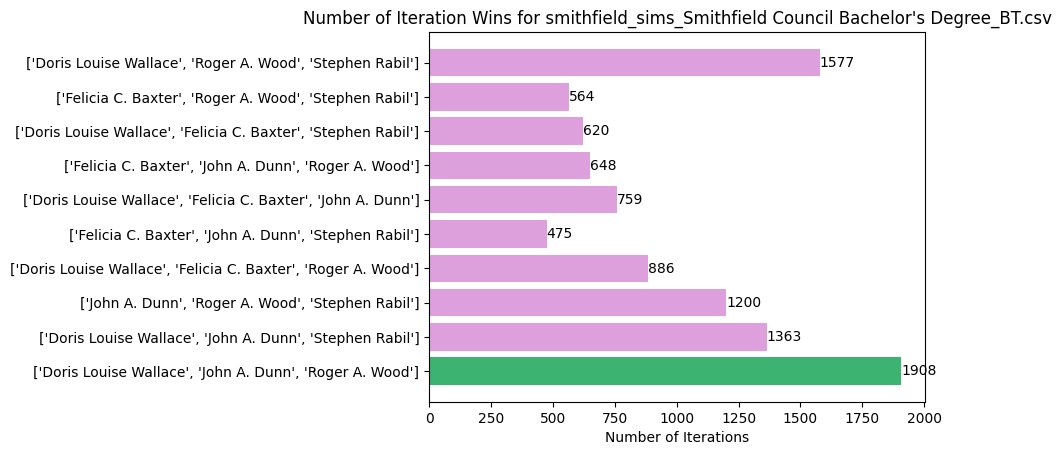

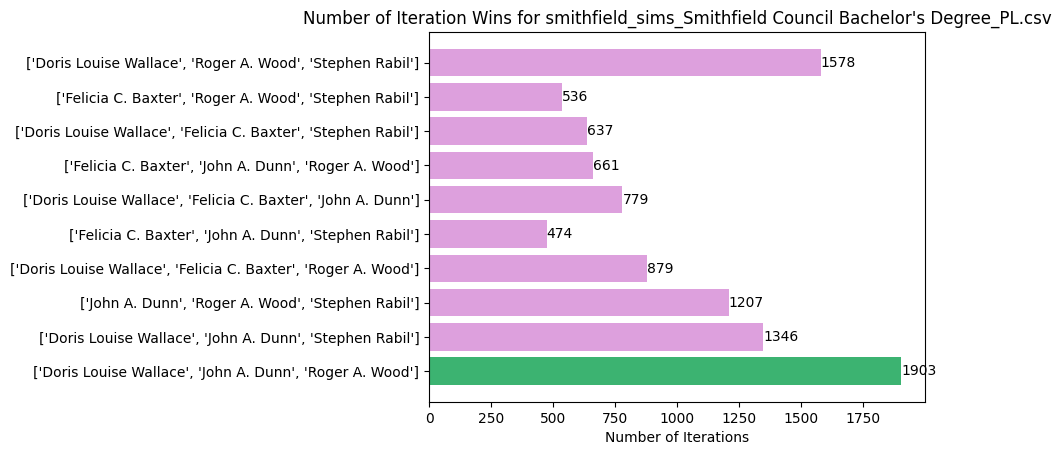

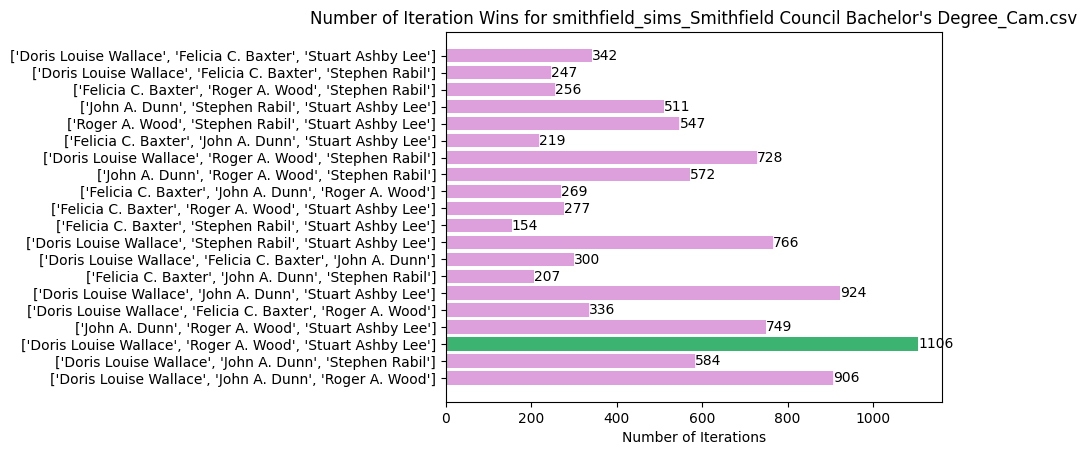

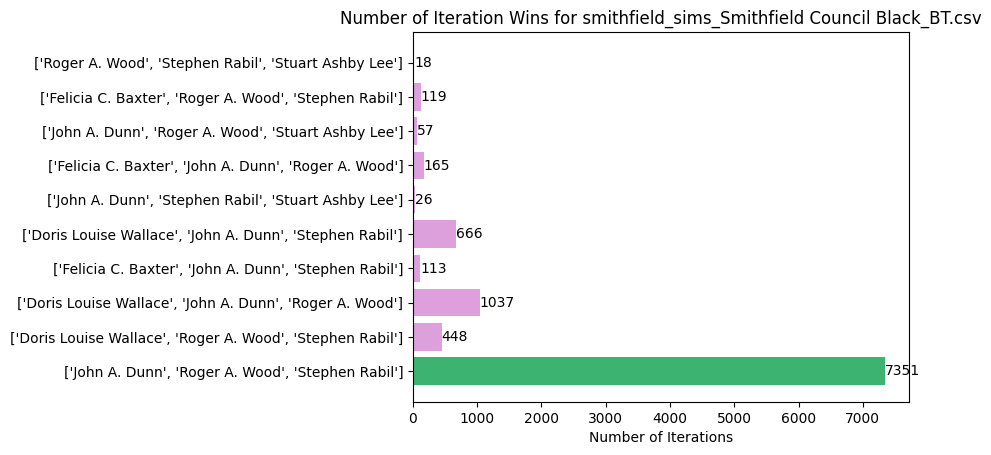

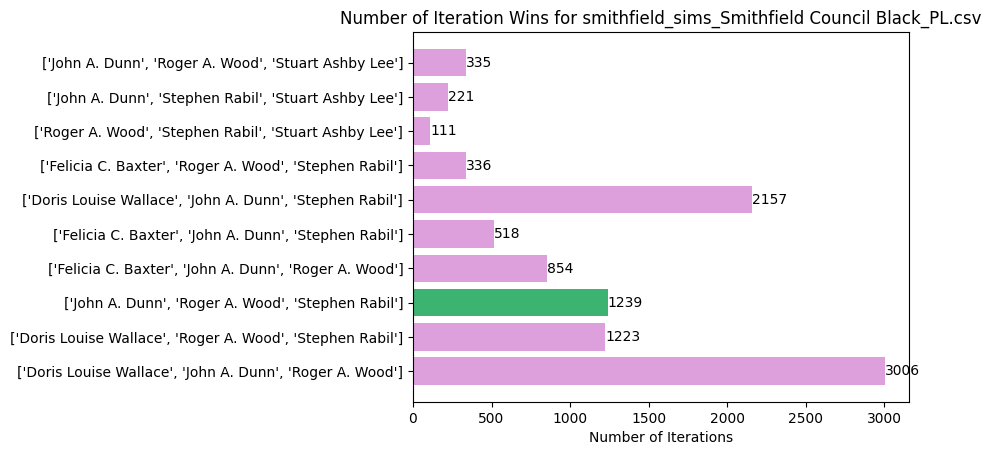

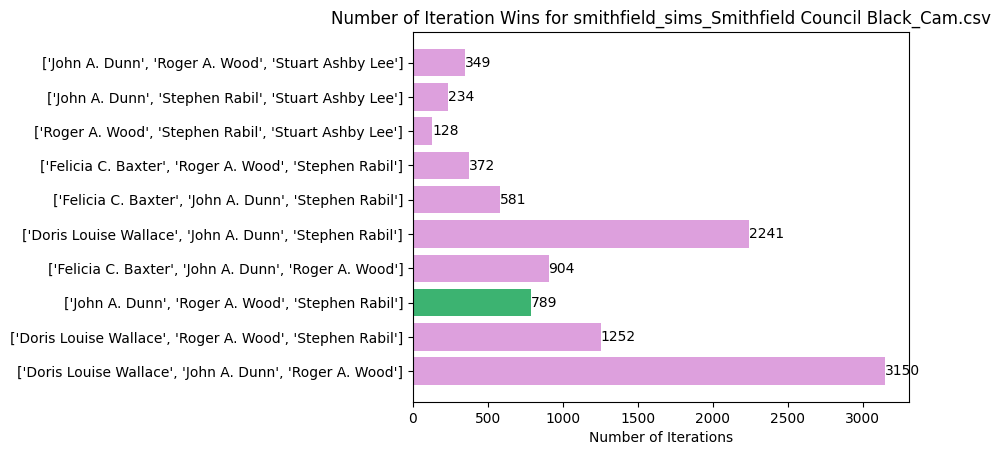

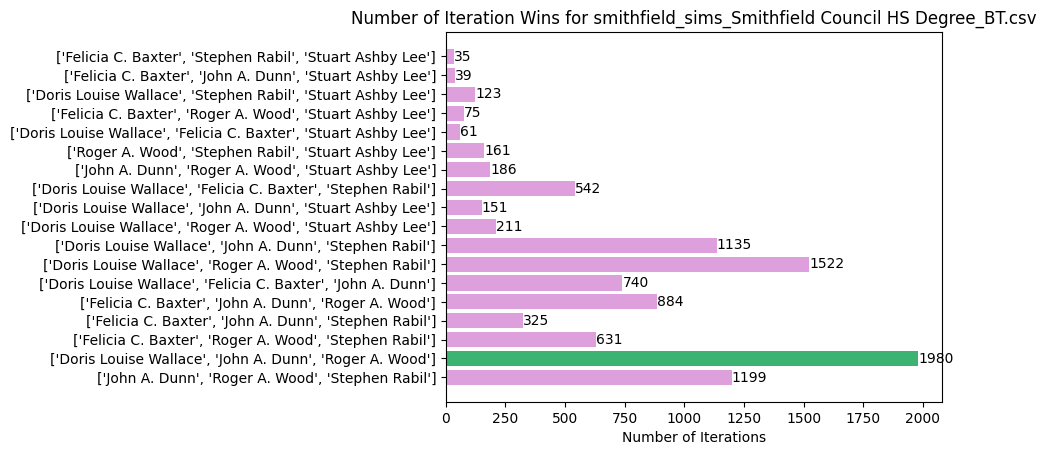

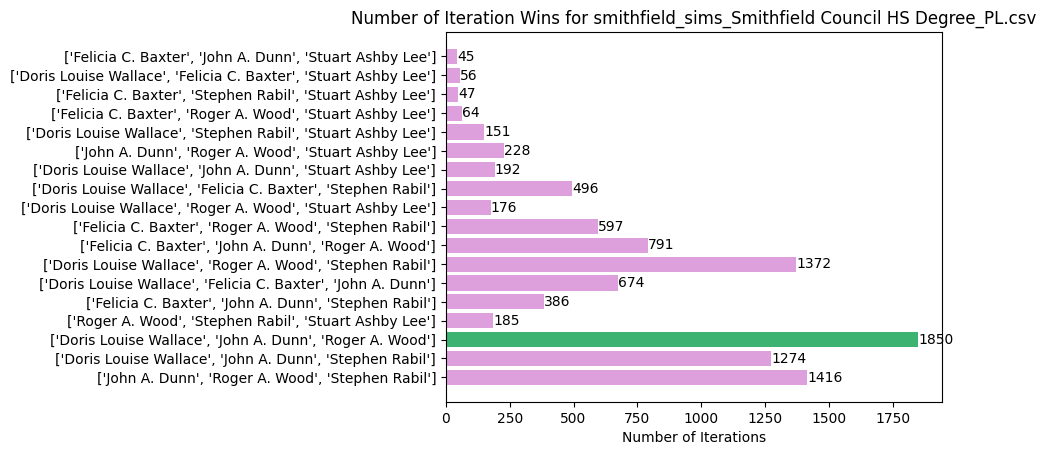

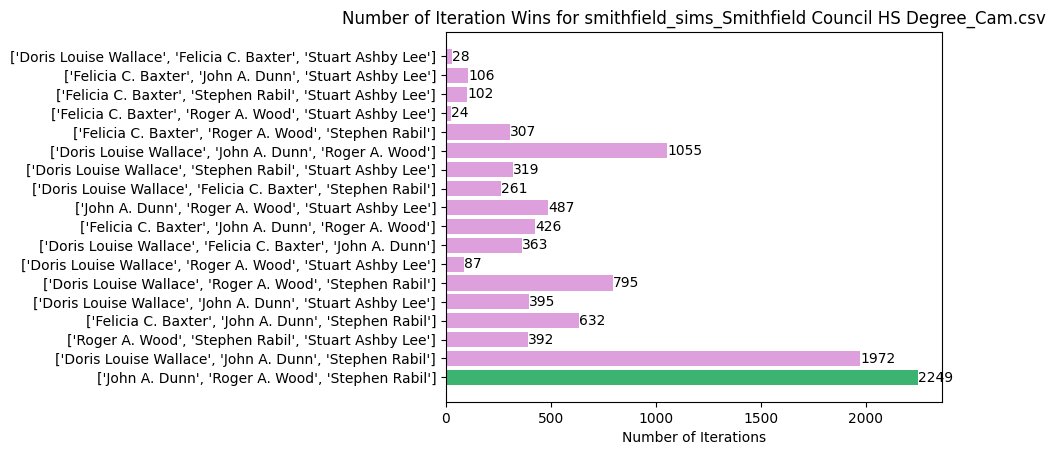

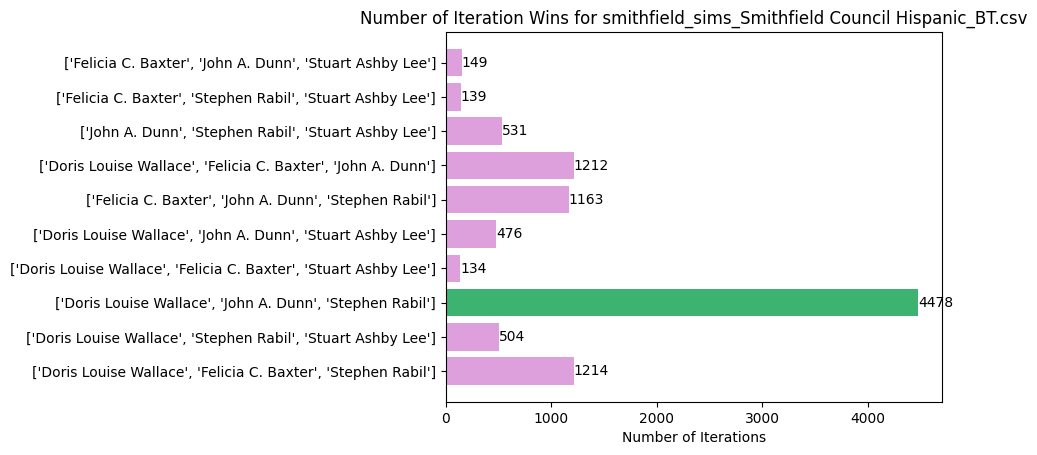

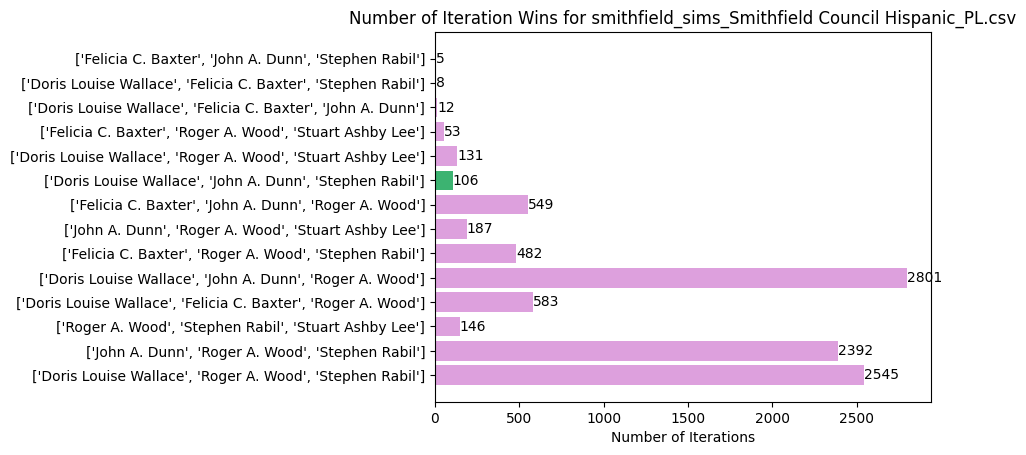

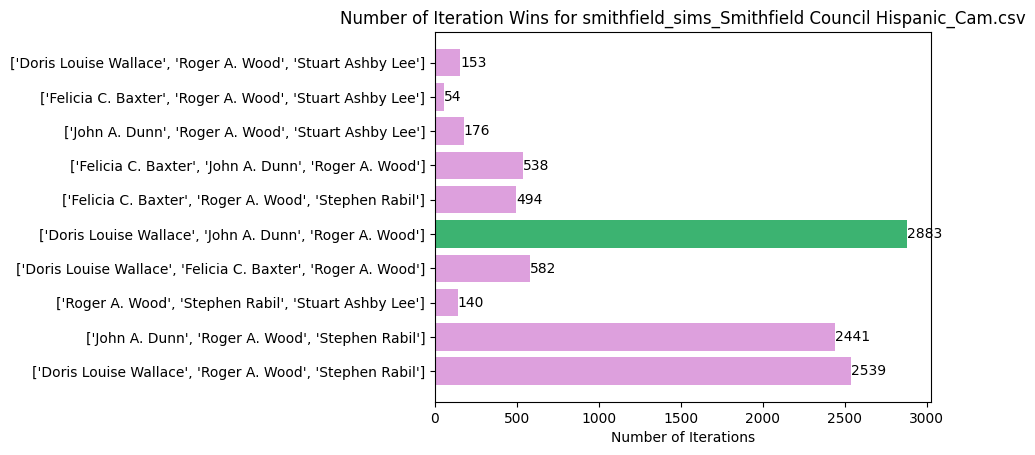

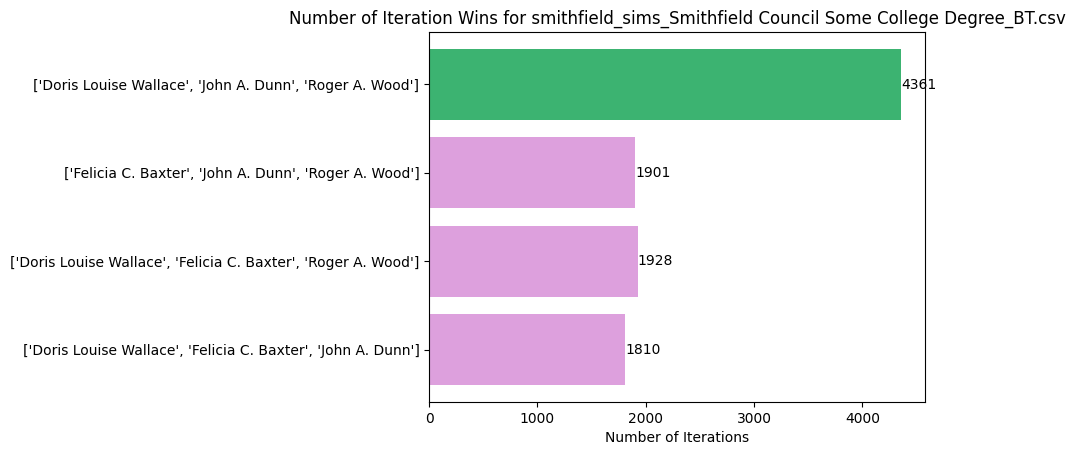

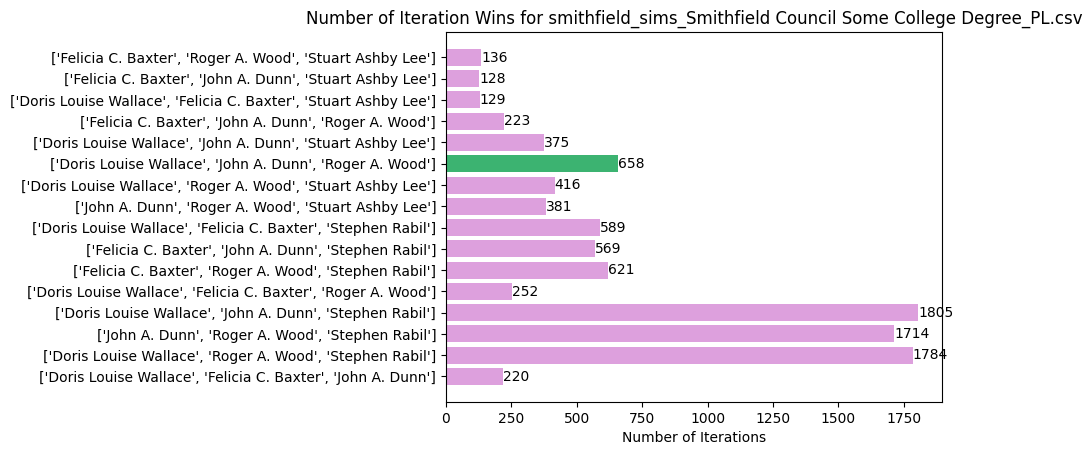

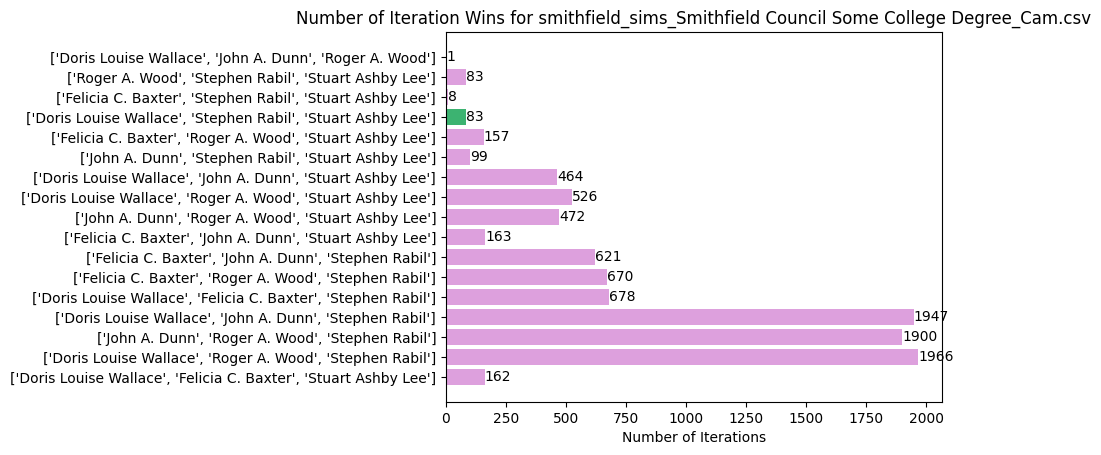

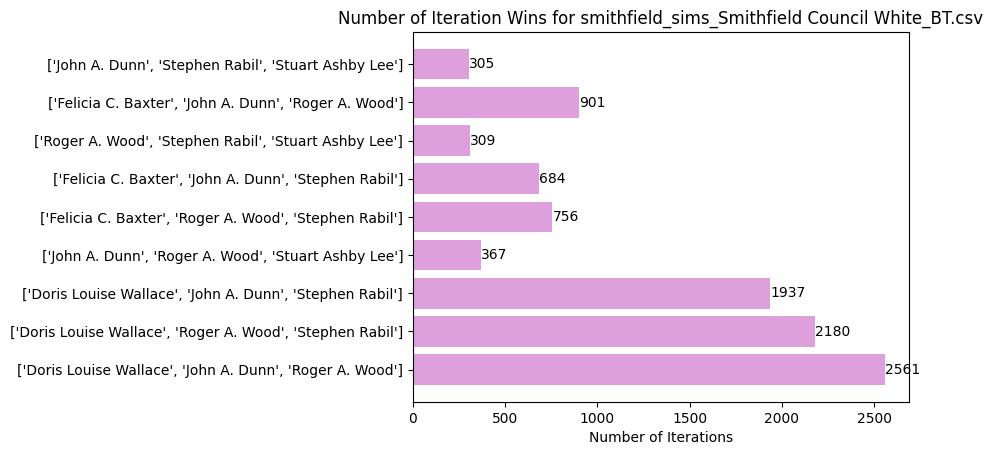

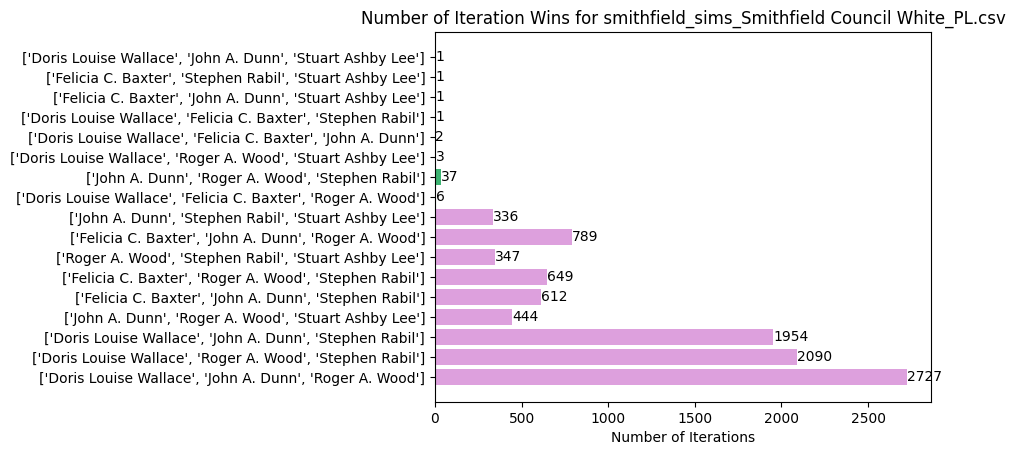

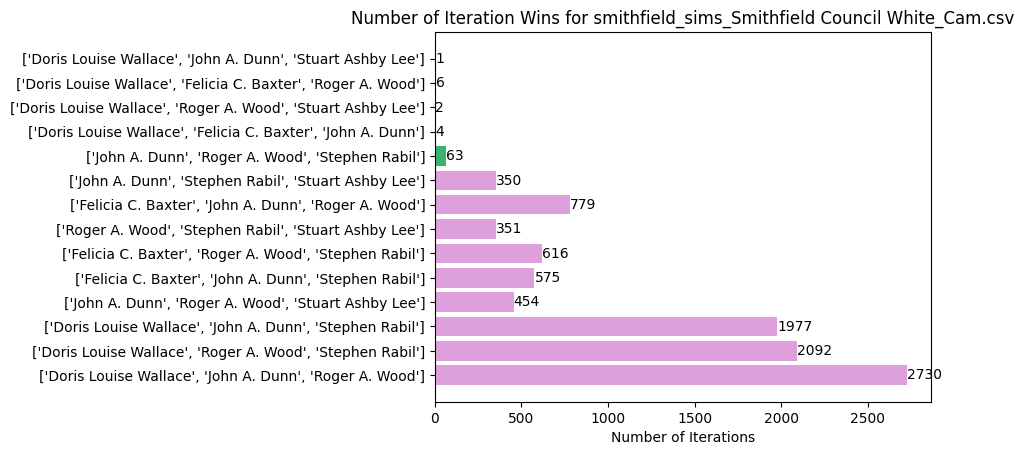

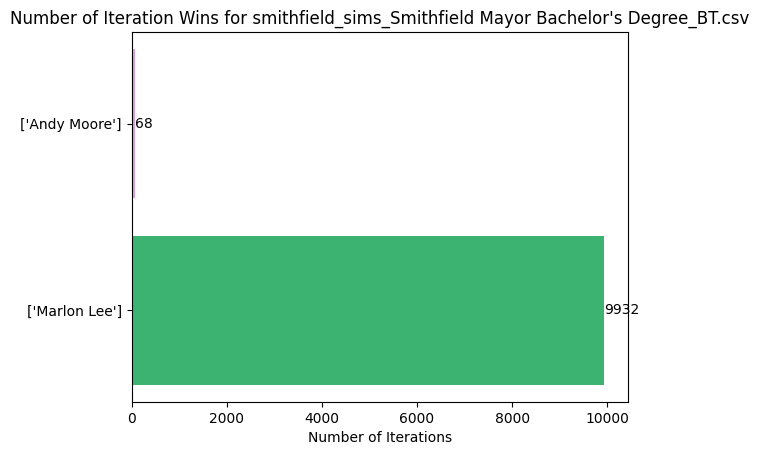

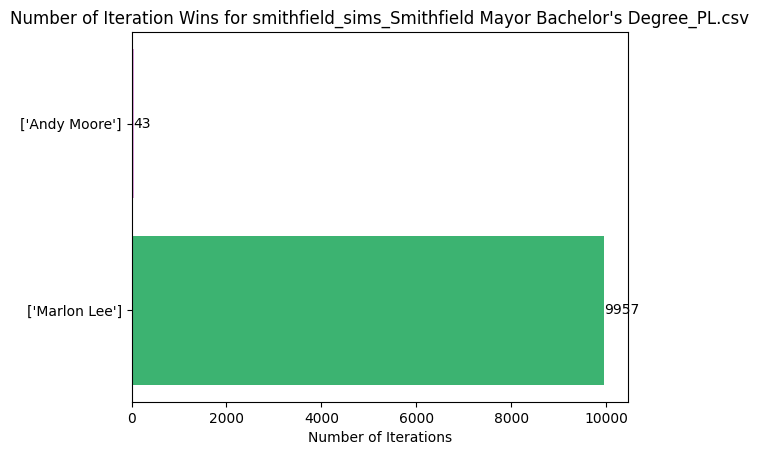

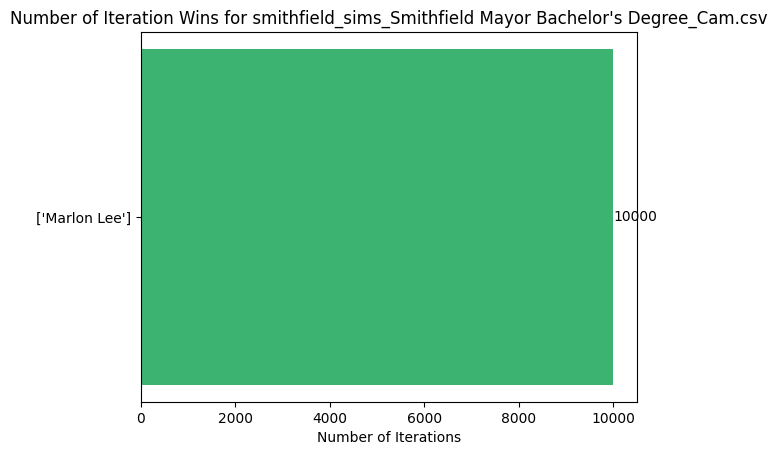

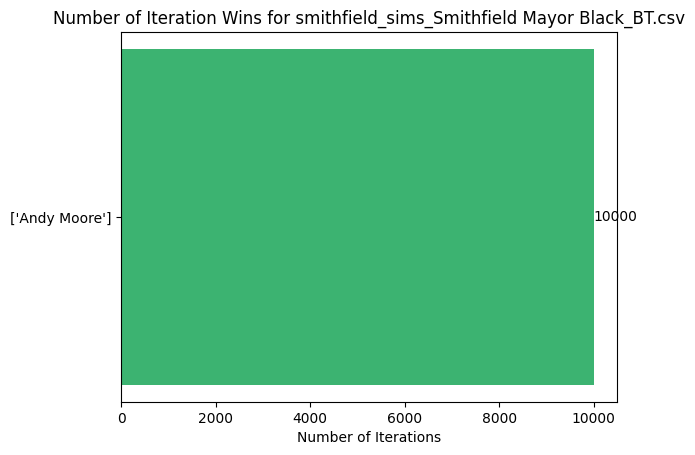

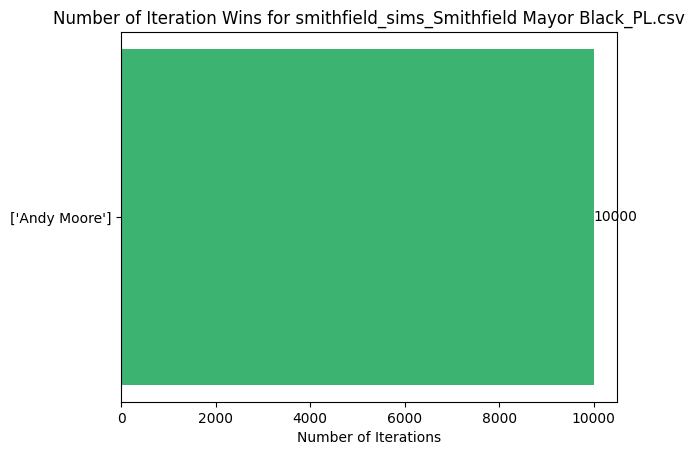

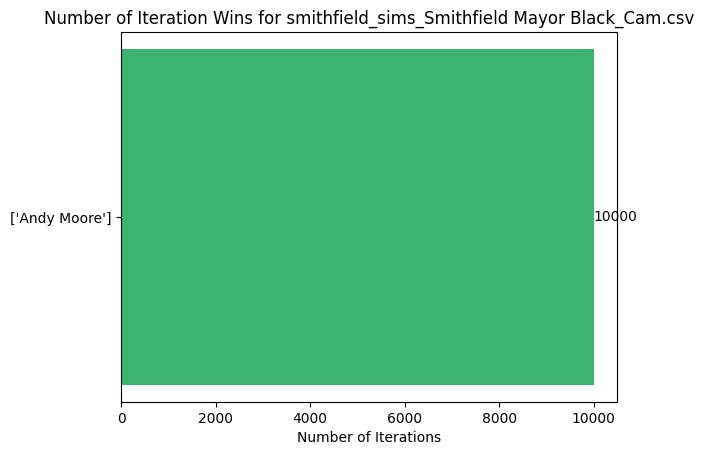

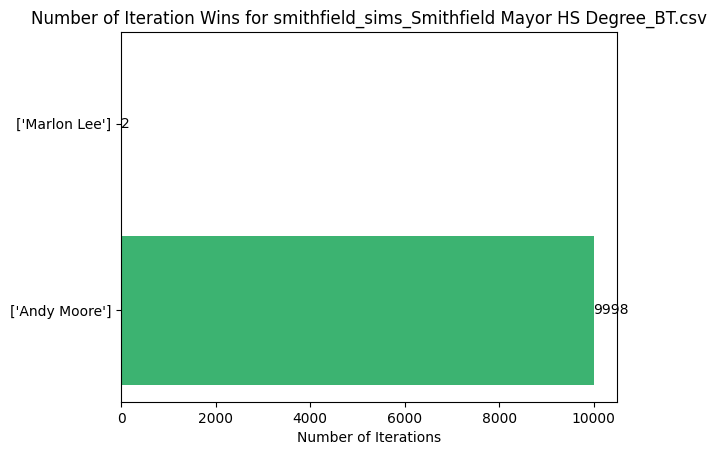

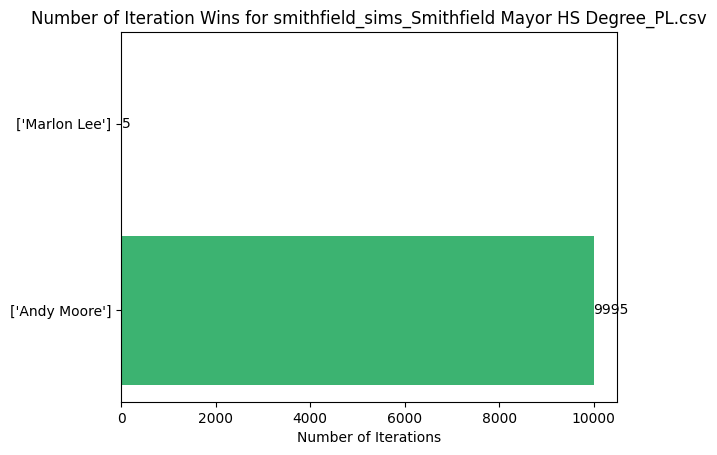

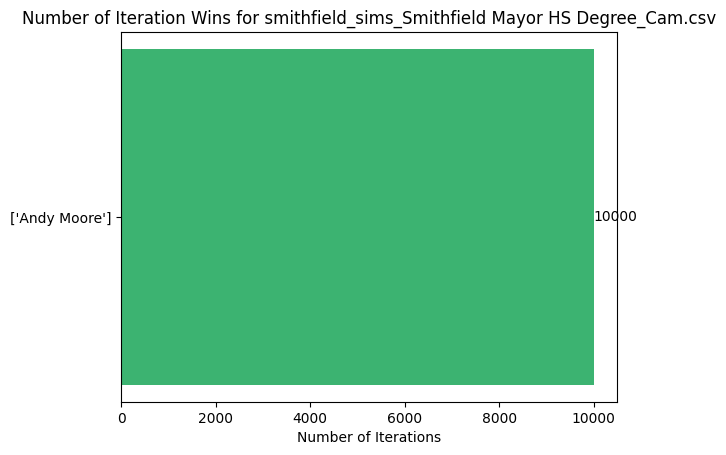

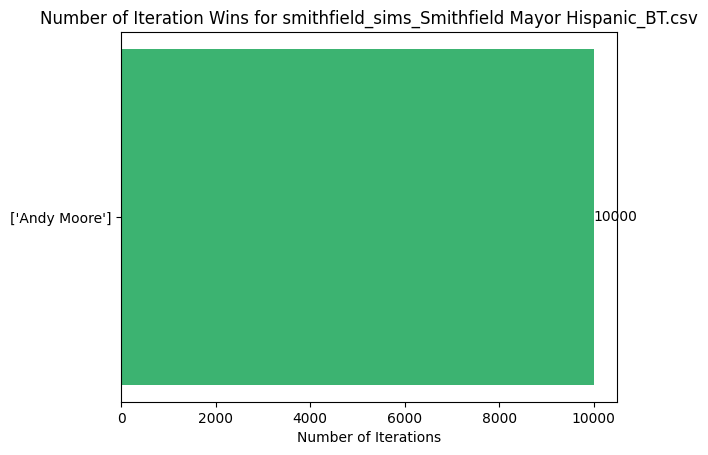

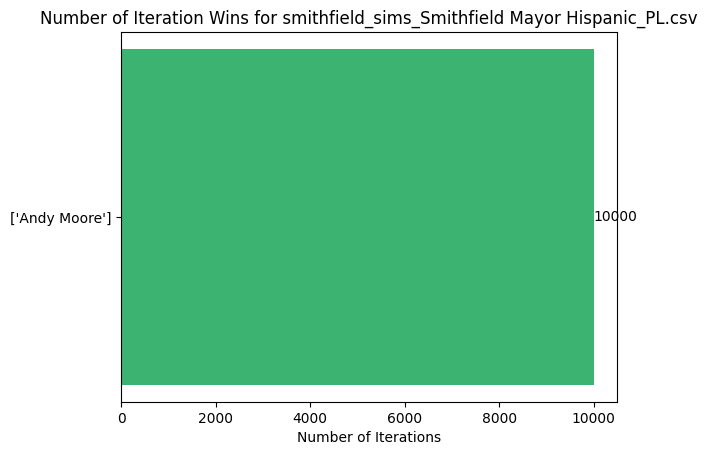

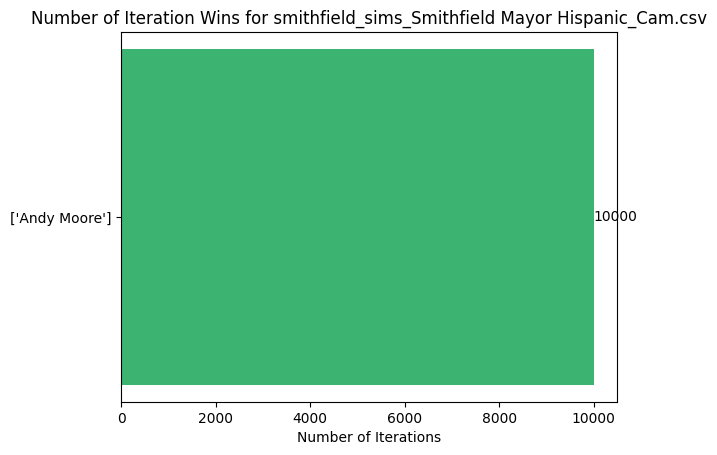

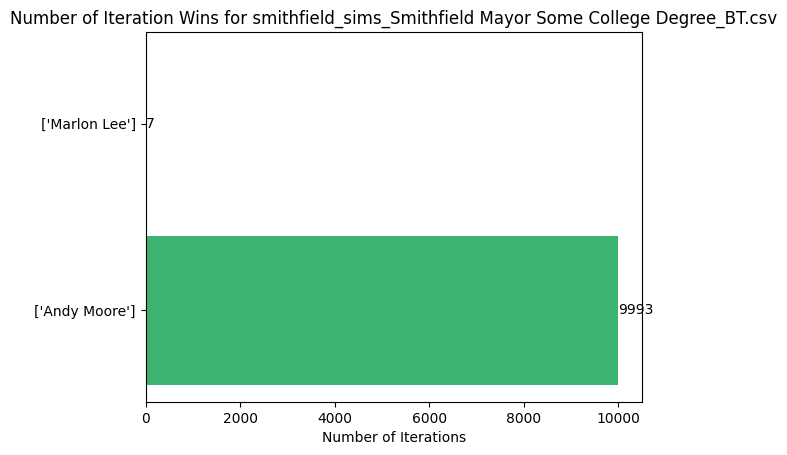

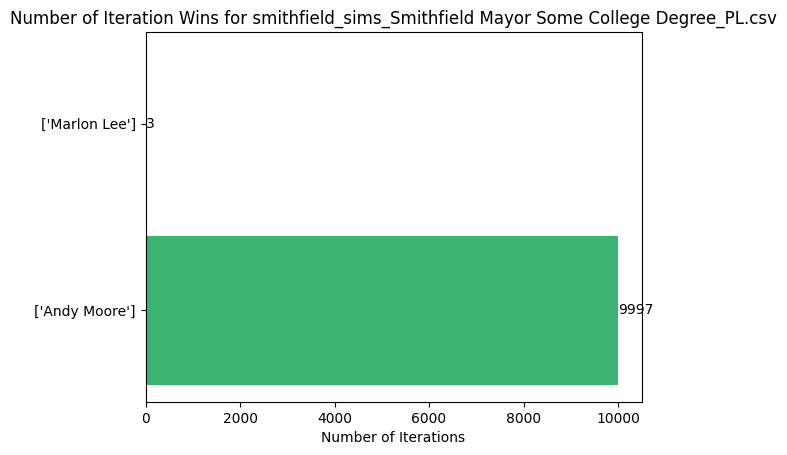

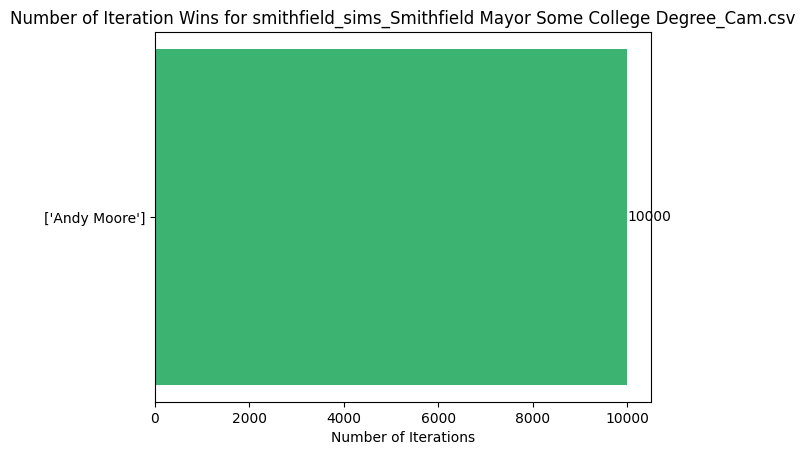

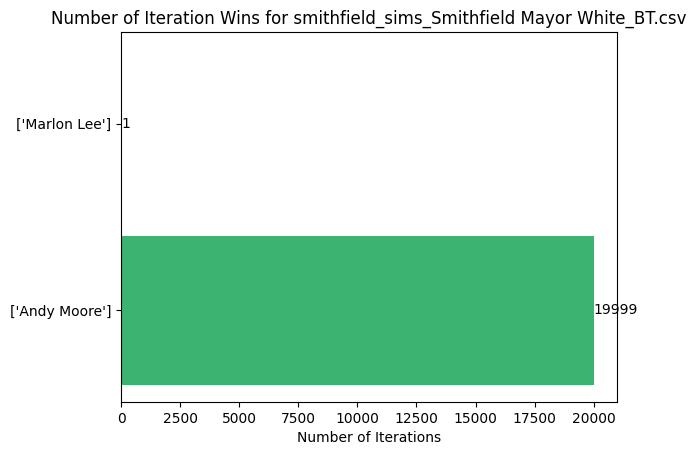

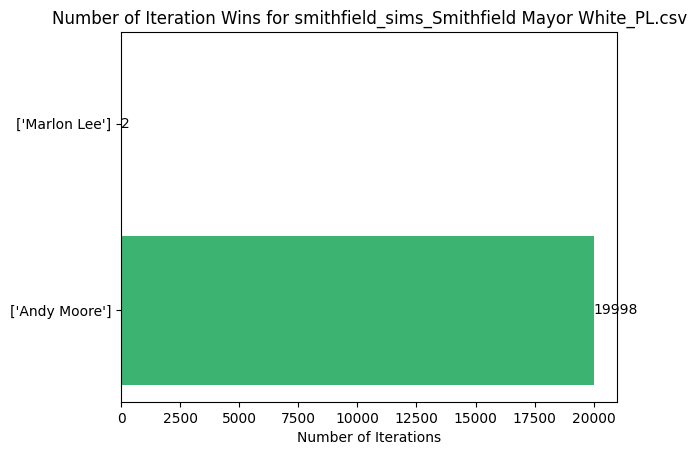

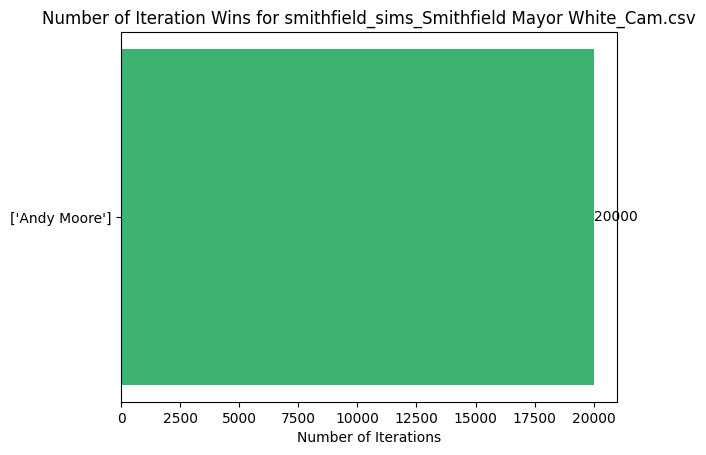

In [ ]:
# Determine Plurality Winner

for i in range(len(df_list)):
    print(csv_titles[i])
    # Get plurality winner to set colors
    num_candidates = int(df_list[i]['Candidate'].isna().idxmax())
   
    df_list[i] = df_list[i].dropna().reset_index()
    grps = df_list[i].groupby(df_list[i].index // num_candidates)
    all_winners = []
    for _, dfg in grps:
        winners = dfg[dfg['Plurality Result'] == True]
        winners = winners['Candidate'] 
        all_winners.append(list(winners))

    all_winners = tuple(all_winners)

    counts = {}
    for j in all_winners:
        j = str(j)
        if j in counts:
            counts[j] += 1
        else:
            counts[j] = 1

    # Inspiration from: https://medium.com/@icodewithben/counting-and-graphing-categorical-data-with-matplotlib-017ac6d4aa73
    winners = list(counts.keys())
    values = list(counts.values())

    # Get overall winner
    plurality_winner = max(counts.items(), key=lambda item: item[1])

    print('plurality winner: ', plurality_winner)

    # Get ranked-choice winnner
    grps = df_list[i].groupby(df_list[i].index // num_candidates)
    all_winners = []
    for _, dfg in grps:
        winners = dfg[dfg['STV Result'] == True]
        winners = winners['Candidate'] 
        all_winners.append(list(winners))

    all_winners = tuple(all_winners)

    counts = {}
    for j in all_winners:
        j = str(j)
        if j in counts:
            counts[j] += 1
        else:
            counts[j] = 1

    # Inspiration from: https://medium.com/@icodewithben/counting-and-graphing-categorical-data-with-matplotlib-017ac6d4aa73
    winners = list(counts.keys())
    values = list(counts.values())

    # Get overall winner
    rcv_winner = max(counts)
    rcv_winner = max(counts.items(), key=lambda item: item[1])

    print('rcv winner: ', rcv_winner)
    # Now, assign colors based on plurality winner
    colors = ['plum' if i != plurality_winner[0] else 'mediumseagreen' for i in winners]

    fig, ax = plt.subplots()
    #ax.barh(winners, values, color = colors)
    ax.barh(counts.keys(), counts.values(), color = colors)
    for container in ax.containers:
        ax.bar_label(container)
    plt.xlabel('Number of Iterations')
    plt.title("Number of Iteration Wins for " + csv_titles[i])